# Spec-5 P1D constrain forescasts based on DESI DR1 pipeline 
Original tutorial from : https://github.com/igmhub/cup1d/blob/main/notebooks/tutorials/forecast_tutorial.py

Author: Jonás Chaves Montero

Contributors for this version: Alma González, Naim Karacayli and Anoma Ganguly

Requirements: cup1d (https://github.com/igmhub/cup1d/)  and lace (https://github.com/igmhub/LaCE).

Note it migth not run out of the box due to some data that might not be in the repository

In [5]:
%load_ext autoreload
%autoreload 2

import numpy as np
import os, sys
import matplotlib.pyplot as plt
from cup1d.likelihood.pipeline import Pipeline
from cup1d.likelihood.input_pipeline import Args
os.environ['NYX_PATH']='/global/cfs/cdirs/desi/science/lya/y1-p1d/likelihood_files/nyx_files/'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load Mock P1D measurements and set likelihood

The mock measurements are created with an emulator

In [6]:
#For now it uses mock P1D data, but real DESI Y1 covariance. 
data_label = "mock_DESIY1_QMLE3"
cov_label = "DESIY1_QMLE3"
fit_type = "global_opt"
name_variation = "no_contaminants"

#mcmc_conf = "explore"  #To get a goog chain
mcmc_conf = "test"    #For testing things works
args = Args(data_label=data_label, cov_label=cov_label)

args.set_baseline(
    fix_cosmo=False,
    fit_type=fit_type,
    P1D_type=cov_label,
    name_variation=name_variation,
    mcmc_conf=mcmc_conf,
)

pip = Pipeline(args)

f_Lya_SiIII -6 -10
f_Lya_SiII -6 -10
f_SiIIa_SiIIb -3 -10
----------
Setting emulator
Select emulator in CH24_mpgcen_gpr
Done setting emulator
----------
----------
Setting P1Ds
Done setting P1Ds
----------
will not store truth, working with real data
Created directory: ./DESIY1_QMLE3/no_contaminants/CH24_mpgcen_gpr/chain_3
setup with  1  ranks,  37  walkers, and  5  steps
combined steps  185 useful steps  185


## Plot Mock P1D data 

100.0


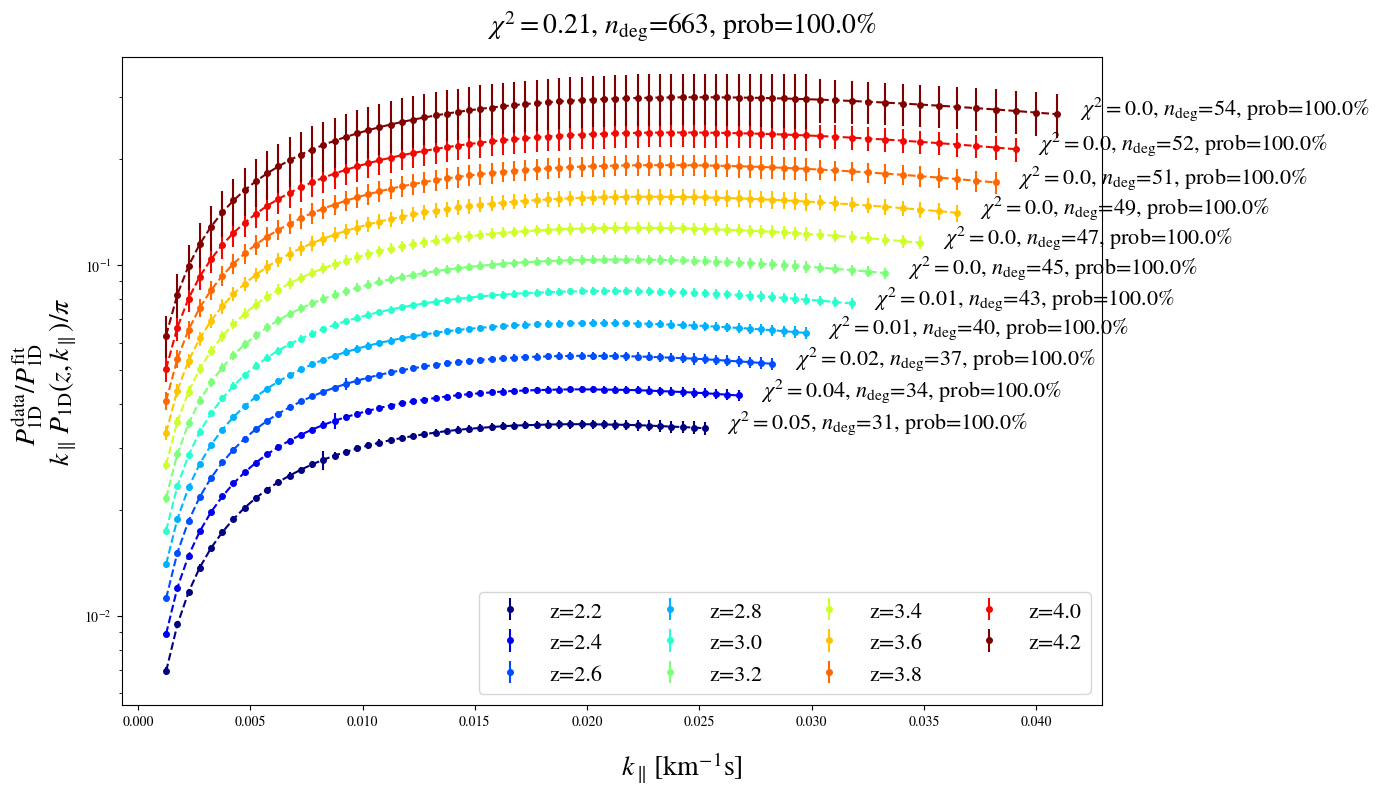

In [7]:
pip.fitter.like.plot_p1d()

In [9]:
#Set here the new forectas covariance matrix
#pip.fitter.like.cov_Pk_kms =
#pip.fitter.like.data.covstat_Pk_kms =

### Compressed parameters

In [12]:
blob = pip.fitter.like.theory.get_blob_fixed_background(ini_free_params)
ini_Delta2_star = blob[0]
ini_n_star = blob[1]
print(ini_Delta2_star, ini_n_star)

0.3542536239628172 -2.2997129860590277


### Run fitter

----------
Running minimizer
Starting NM minimization, chi2= 0.2092110001986369
Step, rep, time 0 0 9.46 9.46
Minimization improved (ini, last, now, diff): 0.2092 0.2092 0.2007 -0.0085
Step, rep, time 1 1 9.26 18.72
Minimization improved (ini, last, now, diff): 0.2092 0.2007 0.2003 -0.0004
Passed out: 0.20028245104095813
updating mle from  10000000000.0 to 0.20028245104095813
Fit params cube: [0.44986084 0.47083351 0.49733809 0.49725046 0.49480715 0.49635441
 0.42353181 0.42369026 0.4255775  0.42840283 0.47591598 0.47666526
 0.47781074 0.48075404 0.39608683 0.39383424 0.40170749 0.39453327]
Fit params no cube: [ 2.11172180e-09  9.66488822e-01  3.65135876e-04  3.26141899e-04
 -7.61017454e-04 -7.25594617e-05  9.97104710e-01  9.97180574e-01
  9.98084199e-01  9.99436984e-01  1.00218810e+00  1.00256364e+00
  1.00313777e+00  1.00461298e+00  1.00451319e+00  1.00342486e+00
  1.00722881e+00  1.00376259e+00]
Results are not blinded
Results are not blinded
Results are not blinded
MLE
Delta2_star 

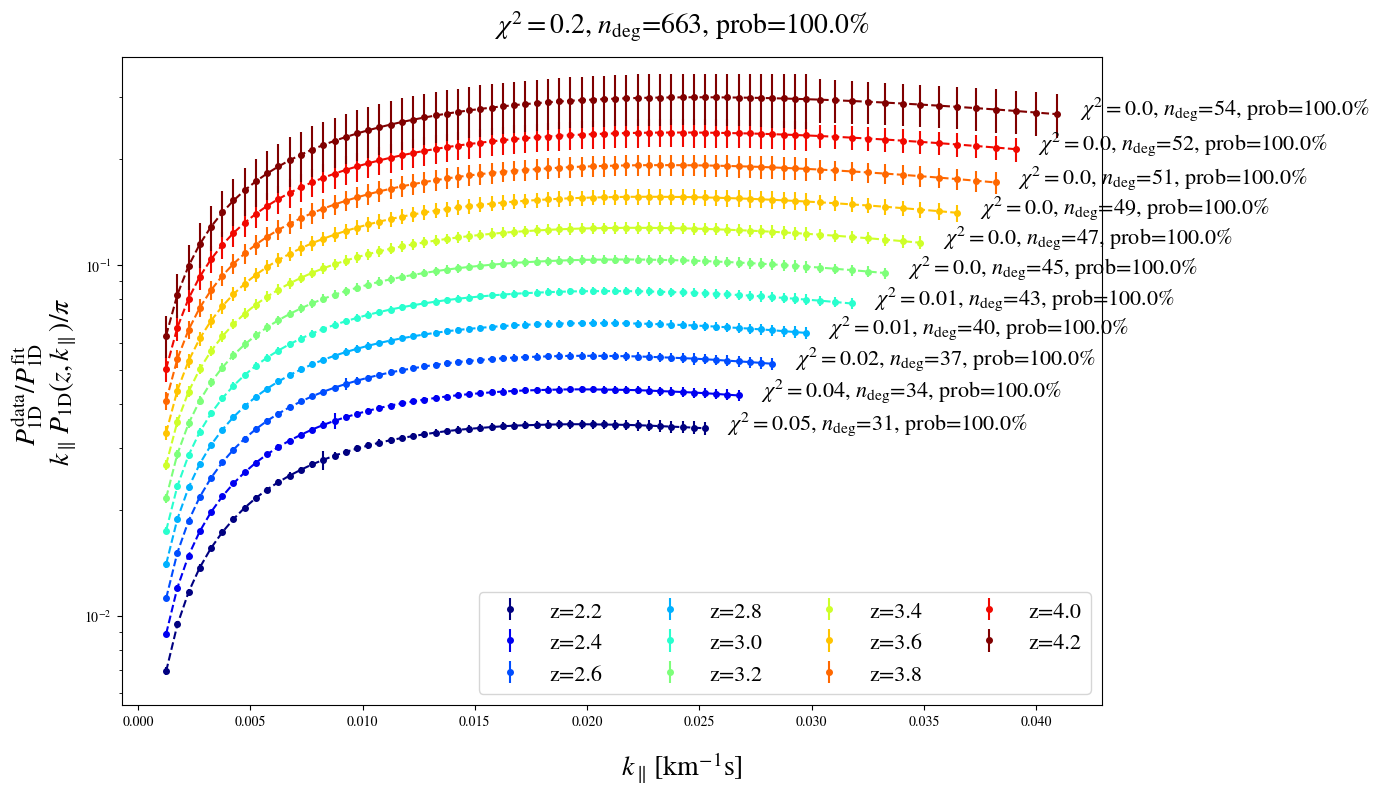

In [13]:
run_fitter = True

if run_fitter:
    p0 = pip.fitter.like.sampling_point_from_parameters()
    pip.run_minimizer(p0, restart=True)
    pip.fitter.like.plot_p1d(pip.fitter.mle_cube)

### Run sampler

In [14]:
run_sampler = True

if run_sampler:
    p0 = pip.fitter.like.sampling_point_from_parameters()
    pip.run_sampler(p0)

----------
Running sampler
set 37 walkers with 18 dimensions
Rank 0 done
Sampler run in 2.45 s
----------
Saving data
Saving data to ./DESIY1_QMLE3/no_contaminants/CH24_mpgcen_gpr/chain_3/fitter_results.npy


In [15]:
Delta2_star = pip.fitter.blobs["Delta2_star"].reshape(-1)
n_star = pip.fitter.blobs["n_star"].reshape(-1)

Text(0.5, 0, '$\\Delta^2_\\mathrm{star}$')

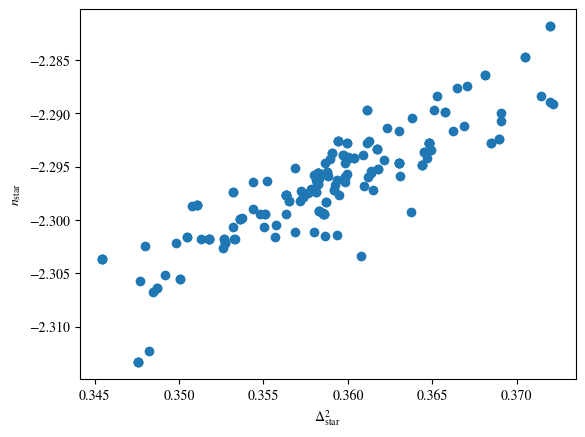

In [16]:
plt.scatter(Delta2_star, n_star)
plt.ylabel("$n_\mathrm{star}$")
plt.xlabel("$\Delta^2_\mathrm{star}$")